In [1]:
import os
import pandas as pd
import numpy as np

In [24]:
from scipy import stats

def perform_welch(list_a, list_b):

    list_a = [x for x in list_a if x < 800.0]
    print(list_b)
    list_b = [x for x in list_b if x < 800.0]

    print(list_a, list_b)
    
    t_stat, p_value = stats.ttest_ind(list_a, list_b, equal_var=False)

    # Significance encoding
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    print(f"Welch's t-test results")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_value:.4g}")
    print(f"significance:{stars}")


In [25]:
DATASET = 'dic'

#### 1. AUC over LNK curve

In [26]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = np.trapz(np.array(l))

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = np.trapz(np.array(l))

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[1101.0191892692421, 7140.047962594677, 109.46291202978885, 15044.679135107688, 2100.251258832988, 2118.6815258325223, 2135.768797867389, 10071.542800321584]
[262.4342233317818, 293.22166039013246, 259.8448356112216, 277.9619176575128, 276.14784411627807, 269.34686666948755, 265.388270638514, 279.42457580501843] [109.46291202978885]
Welch's t-test results
t-statistic: nan
p-value:     nan
significance:ns


#### 2. Best LNK value

In [27]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = max(l)

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = max(l)

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[999.0, 999.0, 0.9987729022976348, 999.0, 999.0, 999.0, 999.0, 999.0]
[0.998603647442136, 0.998476706300512, 0.9983920788727628, 0.9987729022976348, 0.99873058858376, 0.9981805103033892, 0.998222824017264, 0.9989421571531332] [0.9987729022976348]
Welch's t-test results
t-statistic: nan
p-value:     nan
significance:ns


#### 3. LNK value after first epoch

In [28]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[0]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[0]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.9798586721956586, 0.9185461007912664, 0.9600558541023144, 0.9896754538145812, 0.967756950027504, 0.9833283967333812, 0.975754241949816, 0.9777853002158]
[0.961029069521432, 0.9174459442305252, 0.9680954597385012, 0.9195193162103836, 0.8999280666864131, 0.9313248423814158, 0.9116066517158212, 0.9256124910083358] [0.9798586721956586, 0.9185461007912664, 0.9600558541023144, 0.9896754538145812, 0.967756950027504, 0.9833283967333812, 0.975754241949816, 0.9777853002158]
Welch's t-test results
t-statistic: -3.4503
p-value:     0.00392
significance:**


#### 4. LNK value after last measured epoch

In [29]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[-1]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[-1]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.2583675369187154, 0.9630178140735411, 0.258663732915838, 0.0174755638302374, 0.4137858079803664, 0.4084965937460331, 0.6293741801717937, 0.2658147505606567]
[0.6969914949435112, 0.9454999365294292, 0.6878094190327084, 0.745525324757754, 0.6976685143655059, 0.7727753564930394, 0.7765412770278848, 0.7077814919815513] [0.2583675369187154, 0.9630178140735411, 0.258663732915838, 0.0174755638302374, 0.4137858079803664, 0.4084965937460331, 0.6293741801717937, 0.2658147505606567]
Welch's t-test results
t-statistic: 3.3321
p-value:     0.009955
significance:**


#### 5. LNK value at maximum counterfactual and treatment

In [30]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.9981381965895146, 0.2079295899801125, 0.9938645114881732, 0.3301315956501502, 0.0738374307112935, 0.5890068971353616, 0.98032412304828, 0.5183429949646681]
[0.998603647442136, 0.998476706300512, 0.9983920788727628, 0.9987729022976348, 0.99873058858376, 0.9981805103033892, 0.998222824017264, 0.9989421571531332] [0.9981381965895146, 0.2079295899801125, 0.9938645114881732, 0.3301315956501502, 0.0738374307112935, 0.5890068971353616, 0.98032412304828, 0.5183429949646681]
Welch's t-test results
t-statistic: 3.1360
p-value:     0.01647
significance:*


In [9]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 7.0005
p-value:     0.0002115
significance:***


#### 6. Per-Epoch t-test

In [31]:
withs = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["TRA"].to_list()
    withs.append(l)

withouts = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["TRA"].to_list()
    withouts.append(l)


withs = np.array(withs)
withouts = np.array(withouts)


for idx in range(300):
    a = list(withs[:, idx])
    b = list(withouts[:, idx])

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    print(idx, t_stat, p_value, sep='\t')

0	-3.4503064837520148	0.003920216374528825
1	-2.4179432589178984	0.029831281693743772
2	-0.8643231287794825	0.4063806044023651
3	3.616300662941723	0.007987142553511455
4	4.341808539494097	0.0033822850146618933
5	2.4129119604416176	0.046559910294032156
6	2.9055813556762202	0.022794272592487758
7	1.8610697379060772	0.10502998623184907
8	2.19455829497463	0.06182066094717848
9	3.2637192166756814	0.013705841569407826
10	2.419744091633865	0.041724870978526535
11	4.012180489503762	0.005084418203259259
12	4.616040994704586	0.0024348480333447383
13	2.953765712258979	0.02029630649915359
14	3.6594987724970025	0.008047707996530413
15	-0.9954665174461573	0.352667489164149
16	-0.9952391103796943	0.35277060621941686
17	4.202419963047849	0.0036800856125925358
18	3.155774272642022	0.015942520661691335
19	-0.996998462480437	0.3519734331835326
20	3.1726991517173246	0.010615747466452328
21	-0.997425740020232	0.35178003820327075
22	3.343510414175044	0.011983019587376546
23	3.5443419110514762	0.009338508067

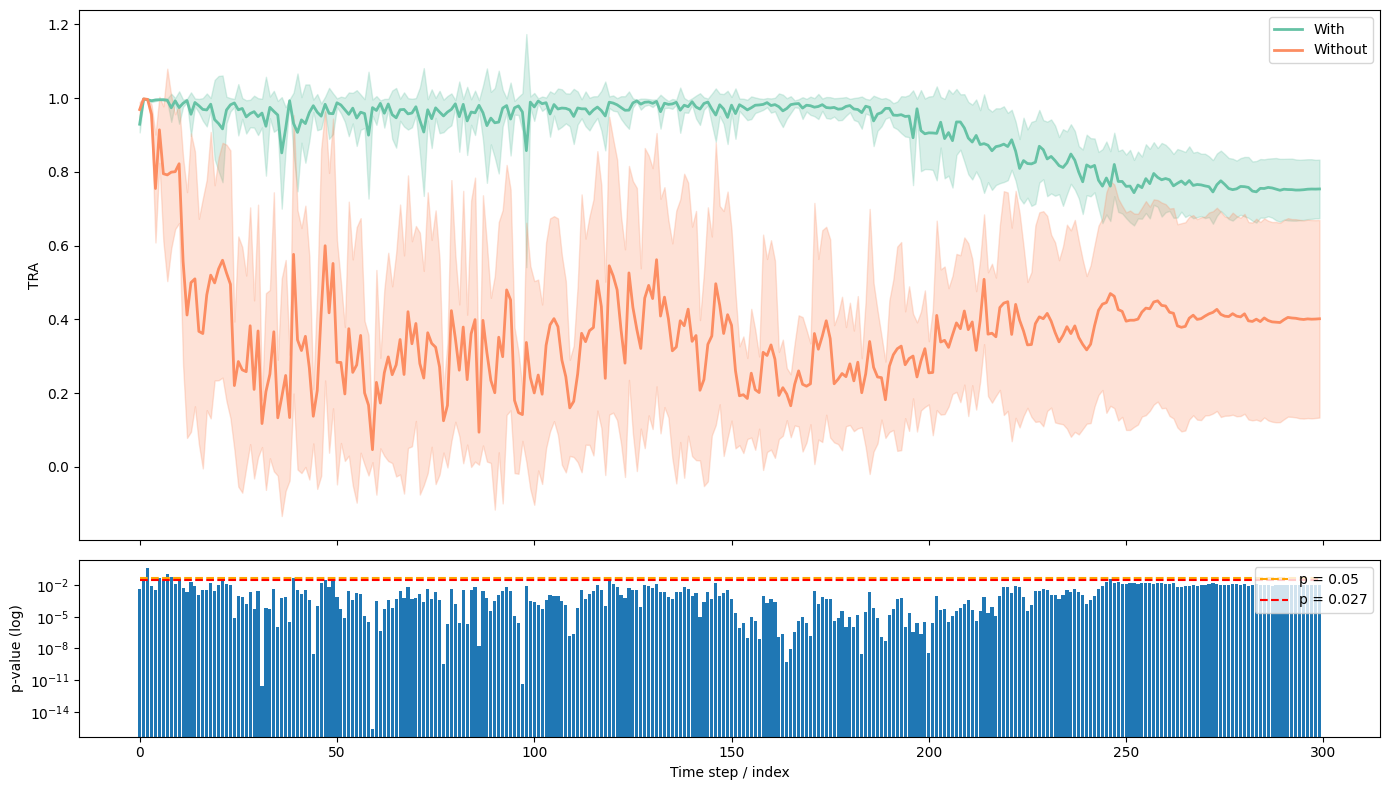

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# -------------------------
# 1) Load your runs (WITH / WITHOUT)
# -------------------------
withs = []
for fname in sorted(os.listdir(f"effects/{DATASET}/with/")):
    df = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = [x if x < 800.0 else None for x in df["TRA"].to_numpy()]
    last = 0.0
    for idx in range(len(l)):
        if l[idx] is None:
            l[idx] = last
        else:
            last = l[idx]
    withs.append(l)

withouts = []
for fname in sorted(os.listdir(f"effects/{DATASET}/without/")):
    df = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = [x if x < 800.0 else None for x in df["TRA"].to_numpy()]
    last = 0.0
    for idx in range(len(l)):
        if l[idx] is None:
            l[idx] = last
        else:
            last = l[idx]
    withouts.append(l)

# Ensure all runs have the same length (truncate to min length if not)
minlen = min(min(map(len, withs)), min(map(len, withouts)))
withs = np.stack([x[:minlen] for x in withs], axis=0)       # shape: (n_runs, T)
withouts = np.stack([x[:minlen] for x in withouts], axis=0) # shape: (n_runs, T)

# -------------------------
# 2) Plot helper: mean ± std shading
# -------------------------
cmap = mpl.colormaps["Set2"]
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, arr2d, color, label):
    """
    arr2d: shape (n_runs, T)
    """
    mean = arr2d.mean(axis=0)
    std  = arr2d.std(axis=0, ddof=0)
    x = np.arange(arr2d.shape[1])

    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25)

# -------------------------
# 3) Compute per-index p-values (Welch by default; set equal_var=True for Student)
# -------------------------
pvals = np.empty(minlen, dtype=float)
tstats = np.empty(minlen, dtype=float)

for idx in range(minlen):
    w = withs[:, idx]
    wo = withouts[:, idx]
    res = stats.ttest_ind(w, wo, equal_var=False, nan_policy="omit")
    tstats[idx] = res.statistic
    pvals[idx]  = res.pvalue

x = np.arange(minlen)

# -------------------------
# 4) Build the combined figure (top: means; bottom: significance)
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TOP ---
plot_mean_shaded(ax_top, withs, ca, "With")
plot_mean_shaded(ax_top, withouts, cb, "Without")
ax_top.set_ylabel("TRA")  # or "Score" / your metric name
# Optional: uncomment if you want the same y-limits as your example
# ax_top.set_ylim(0.90, 1.0)
ax_top.legend(loc="best")

# --- BOTTOM ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("p-value (log)")
ax_bottom.set_xlabel("Time step / index")

# threshold lines
ax_bottom.hlines(0.05, x.min(), x.max(), color="orange", linestyle="--", label="p = 0.05")
ax_bottom.hlines(0.027, x.min(), x.max(), color="red", linestyle="--", label="p = 0.027")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("with_without_plus_significance.pdf", bbox_inches="tight")
plt.show()
